## Step 1: Load each CSV

In [1]:
import os

for file in os.listdir():
    if file.endswith('.csv'):
        print(f'File name: {file}')

File name: order_details.csv
File name: categories.csv
File name: products.csv
File name: customers.csv
File name: orders.csv


In [2]:
import pandas as pd

categories = pd.read_csv('categories.csv')
customers = pd.read_csv('customers.csv')
orders = pd.read_csv('orders.csv')
order_details = pd.read_csv('order_details.csv')
products = pd.read_csv('products.csv')

## Step 2: Look at each one individually

In [20]:
# Checking for missing values in the dataset
def check_null(df):
    """This function check for null values in the loaded datasets"""
    print(df.isna().sum())

check_null(customers)

CustomerID         0
Gender             0
Age                0
City               0
Region             0
CustomerSegment    0
SignUpDate         0
dtype: int64


In [19]:
for name, df in [('categories', categories), ('customers', customers),
                ('orders', orders), ('order_details', order_details),
                ('products', products)]:
    print()

## Step 3: Also open the .db file -- this uses your SQL knowledge directly

In [4]:
import sqlite3

# This opens a connection to the .db file (similar to connecting to MySQL)
conn = sqlite3.connect('retail_store.db')

In [5]:
# See what tables exist inside it
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';", conn
)
print(tables)

            name
0     categories
1       products
2      customers
3         orders
4  order_details


### Step explanation:

- **sqlite3.connect('retail_store.db')** -- this opens a connection to the .db file, similar to how you'd connect to MySQL with a username/password, except SQLite databases are just a single file on disk -no server, no login needed. Conn is now your "pipe" to that database.
- **sqlite_master** -- this is a special built-in table that every SQLite database automatically has. It stores metadata about listing of every table, index, and view inside it.
- **pd.read_sql(...)** -- instead of manually running the query and looping through results, this pandas functiion runs the SQL query and immediately hands you back the result as a dataframe -- combining SQL and pandas in one step

## Step 4: Peek at each table's structure using SQL

In [10]:
query = """
SELECT *
FROM customers
LIMIT 5;
"""

pd.read_sql(query, conn)

,CustomerID,Gender,Age,City,Region,CustomerSegment,SignUpDate
0,CSTMR0001,Male,29,Istanbul,Marmara,Standard,2020-04-13
1,CSTMR0002,Other,40,Istanbul,Marmara,Standard,2020-04-08
2,CSTMR0003,Female,36,Bursa,Marmara,Premium,2022-08-14
3,CSTMR0004,Male,18,Istanbul,Marmara,Premium,2022-03-26
4,CSTMR0005,Male,43,Izmir,Aegean,Premium,2021-04-04


In [11]:
customers['CustomerSegment'].value_counts()

CustomerSegment
Standard    598
Premium     308
VIP          94
Name: count, dtype: int64

### Step explained  

- **SELECT * FROM orders** -- standard SQL: grab every column from the orders table.
- **LIMIT 5** -- only return 5 rows, just to peek at the structure without pulling the entire table.
- **pd.read_sql(query, conn)** -- runs the query against the same connection from Step 3, and returns it as a pandas dataframe you can view/manipulate normally.

**Reason:** Once we know a table's name, we look inside it to see its actual columns and sample data -- this tells us how it might connect to the CSV files you already loaded (e.g,**if orders has a customer_id** column, that's the link to your **customers.csv**)

In [12]:
customers['CustomerSegment'].value_counts()

CustomerSegment
Standard    598
Premium     308
VIP          94
Name: count, dtype: int64

- These customers made orders, let's join the orders and have a look.
- But first we check for null values in the dataset to make sure that it's clean.

In [22]:
orders.isna().sum()

OrderID       0
CustomerID    0
OrderDate     0
OrderTime     0
dtype: int64

In [31]:
customers['CustomerSegment'].value_counts()

CustomerSegment
Standard    598
Premium     308
VIP          94
Name: count, dtype: int64

We see that number of customers in each segment, we can have a look at the customers order behavior using segments

In [30]:
customer_orders = customers.merge(orders, on='CustomerID')

customer_orders['CustomerSegment'].value_counts()

CustomerSegment
Standard    6025
Premium     2970
VIP         1005
Name: count, dtype: int64

- Let's group the customers in Segments.

In [29]:
vip_customers = customer_orders[customer_orders['CustomerSegment'] == 'VIP']
premium_customers = customer_orders[customer_orders['CustomerSegment'] == 'Premium']
standard_customers = customer_orders[customer_orders['CustomerSegment'] == 'Standard']

In [25]:
query = """
SELECT *
FROM customers c
JOIN orders o ON c.CustomerID = o.CustomerID
LIMIT 5;
"""

pd.read_sql(query, conn)

,CustomerID,Gender,Age,City,Region,CustomerSegment,SignUpDate,OrderID,CustomerID,OrderDate,OrderTime
0,CSTMR0001,Male,29,Istanbul,Marmara,Standard,2020-04-13,ORD01106,CSTMR0001,2022-11-25,20:40:58
1,CSTMR0001,Male,29,Istanbul,Marmara,Standard,2020-04-13,ORD04223,CSTMR0001,2021-09-15,20:10:22
2,CSTMR0001,Male,29,Istanbul,Marmara,Standard,2020-04-13,ORD06127,CSTMR0001,2025-05-10,08:27:31
3,CSTMR0001,Male,29,Istanbul,Marmara,Standard,2020-04-13,ORD06323,CSTMR0001,2024-03-01,21:01:51
4,CSTMR0001,Male,29,Istanbul,Marmara,Standard,2020-04-13,ORD07737,CSTMR0001,2025-05-19,21:19:18


So the relationship chain is:  
customers -> orders -> order_details -> products -> categories

## Step 5: Look inside order_details (from the database)

In [ ]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('retail_store.db')

In [ ]:
query = """
SELECT *
FROM Order_Details
LIMIT 5;
"""
pd.read_sql(query, conn)

- **What this does:** connects to **retail_store.db**, and pull the first 5 rows from the order_detaills table so we can see its columns and sample data. 

Let's break down what each column means, since this table is the heart of your dataset (it's where the actual transactions live).

### Understanding order_details
- **OrderID** ->	Which order this item belongs to (links to orders table)
- **ProductID** ->	Which product was bought (links to products table)
- **Quantity** ->	How many units were bought
- **UnitCost** ->	What it cost the store to acquire one unit (their cost price)
- **UnitPrice** ->	What the customer was charged per unit (selling price)
- **DiscountRate** ->	Any discount applied (0.05 = 5% off)
- **IsReturned** ->	0 = not returned, 1 = returned
- **ReturnDate / ReturnTime** ->	When it was returned (notice 9999-12-31 — this is a placeholder meaning "not returned," not a real date)
- **ReturnReason** ->	Why it was returned (None here, since nothing was returned in these rows)

**One important thing to notice:** each row here is one **product line** within an order, not one order, ie OrderID **ORD00002** - it appears twice, because that single order contained two different products.

In [ ]:
## Let's retrieve the order details made by ORD00002
query = """
SELECT *
FROM Order_details
WHERE OrderID = 'ORD00002';
"""
pd.read_sql(query, conn)

### Step 6: First JOIN - connect orders to customers

In [ ]:
query = """
SELECT 
    o.OrderID,
    c.CustomerID,
    o.OrderDate,
    c.CustomerSegment,
    od.Quantity,
    od.UnitPrice,
    (od.Quantity * od.UnitPrice) as TotalPaid,
    p.ProductName
FROM orders o
JOIN customers c ON o.CustomerID = c.CustomerID
JOIN order_details od ON o.OrderID = od.OrderID
JOIN products p ON od.ProductID = p.ProductID
WHERE o.CustomerID = 'CSTMR0703'
ORDER BY o.OrderDate DESC
LIMIT 5;
"""
# orders made by one customer
pd.read_sql(query, conn)

**Why this matters:** on its own, orders only shows you a CustomerID code like CSTMR0703 - meaningless without context. This join lets you see where that customer is from and other details about that customer, right alongside their order.  

The real power is this: you can now group and filter by things that weren't originally attached to orders at all.  

For example, with this joined view you could now ask:
- "Which city generate the most orders"
- "Do VIP customers order more often than Standard customers"
- "Is there a region where sales are growing or shrinking?"

None of those questions were answerabel from orders alone - you needed customers' columns attached to make them askable. That's the core idea: joining doesn't just add columns for decoration, it unlocks entirely new questions you can ask of the data.

In [ ]:
customer_orders = orders.merge(customers, on='CustomerID')

import matplotlib.pyplot as plt
import seaborn as sns

# Which city generated the most orders?
sns.countplot(data=customer_orders, x='City')
plt.title('Order by City Distribution')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Orders Count')
plt.xlabel('City')
plt.show()

In [ ]:
# Do VIP customers order more often than Standard customers?
customer_orders['CustomerSegment'].value_counts()

### Step 7:A biggener join - revenue per product category

In [ ]:
query = """
SELECT 
    cat.CategoryName,
    SUM(od.Quantity * od.UnitPrice) AS TotalRevenue
FROM order_details od
JOIN products p ON od.ProductID = p.ProductID
JOIN categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName
ORDER BY TotalRevenue DESC;
"""
pd.read_sql(query, conn)

### Next step - customer spending using pandas instead of SQL

In [ ]:
# Merge order_details to orders
customers_orders = orders.merge(order_details, on='OrderID')

# Create a new column named 'Revenue'
customers_orders['Revenue'] = customers_orders['Quantity'] * customers_orders['UnitPrice']

top_customers = customers_orders.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
print(top_customers)

### Briefly:  
- **merge()** = pandas' version of JOIN (connects orders+order_details on OrderID)
- **.groupby('CustomerID')** = same as SQL's GROUP BY
- **.sort_values() + .head(10)** = top 10 spenders

Result: **CSTMR0127** is the top spender at $3,396.19 - but notice how close the rest of the top 10 are (mostly $2,700–$3,100), suggesting no single customer dominates spending.

### Next step — add customer details to these top spenders (merge with customers table)

In [ ]:
# Turns CustomerID from an index back into a normal column
top_customers_df = top_customers.reset_index()

# Merging full details to the top 10 customers
top_customers_full_details = top_customers_df.merge(customers, on='CustomerID')

top_customers_full_details

### Briefly:  

- **.reset_index()** turns the CustomerID from an index back into a normal column (needed to merge)
- **.merge(customers, on='CustomerID')** attaches City, Segement, Age, etc. to each top spender.

### Now we can visualize category revenue as a chart

In [ ]:
products.head()

In [ ]:
query = """
SELECT 
    cat.CategoryName,
    SUM(od.Quantity * od.UnitPrice) AS TotalRevenue
FROM order_details od
JOIN products p ON od.ProductID = p.ProductID
JOIN categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName
ORDER BY TotalRevenue DESC;
"""
category_revenue = pd.read_sql(query, conn)

category_revenue

In [ ]:
# For visualization we import matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(category_revenue['CategoryName'], category_revenue['TotalRevenue'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Revenue')
plt.title('Total Revenue by Category Name', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Meat & Poultry were over every other category - visually confirms  

### How it connects to top spenders:  

These are two different "slices" of the same underlying data (order_details), just grouped differently:  

- This chart = grouped by CategoryName -> shows what sells best overall
- Top spenders table = grouped by CustomerID -> shows who spends the most overall

They're not directly linked yet - you don't know if the top spender (CSTMR0127) actually bought Meat&Poultry specifically. To connect them, we'd need a new query grouping by both category AND customer.  

### See what CSTMR0127(#1 spender) actually bought:

In [ ]:
customers.head()

In [ ]:
query = """
SELECT 
    o.OrderID,
    o.OrderDate,
    p.ProductID,
    p.ProductName,
    cat.CategoryName,
    od.Quantity,
    od.UnitPrice,
    (od.Quantity * od.UnitPrice) AS TotalPaid
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN Order_details od ON o.OrderID = od.OrderID
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories cat ON p.CategoryID = cat.CategoryID
WHERE c.CustomerID = 'CSTMR0127'
ORDER BY TotalPaid DESC
LIMIT 5;
"""
pd.read_sql(query, conn)

**Question:** Which city brings in the most total revenue?

In [ ]:
query = """
SELECT
    p.ProductID,
    p.ProductName,
    cat.CategoryName
FROM Products p
JOIN Categories cat ON p.CategoryID = cat.CategoryID
LIMIT 13, 10;
"""
pd.read_sql(query, conn)

In [ ]:
import seaborn as sns

In [ ]:
query = """
SELECT 
    c.City,
    SUM(od.Quantity * od.UnitPrice) AS TotalRevenue
FROM orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN Order_details od ON o.OrderID = od.OrderID
GROUP BY city
ORDER BY TotalRevenue DESC
"""
city_totalRevenue = pd.read_sql(query, conn)

plt.figure(figsize = (10, 15))
sns.barplot(data=city_totalRevenue, x='City', y='TotalRevenue')
plt.title('Total Revenue Per City')
plt.xlabel('Total Revenue')
plt.ylabel('City')
plt.xticks(rotation = 45, ha='right')
plt.tight_layout
plt.show()

**Answer:** From this plot I can easiy see the "Istabul" is the city with the higest revenue  

**One thing worth checking before desciding:** is Istanbul's highest revenue just because it has more customers, or because each customer there spends more? Those lead to different decisions.  

- Quick follow-up query -average revenue per customer, by city:

In [ ]:
query = """
SELECT 
    c.City,
    COUNT(DISTINCT c.CustomerID) AS NumCustomers,
    SUM(od.Quantity * od.UnitPrice) AS TotalRevenue,
    SUM(od.Quantity * od.UnitPrice) / COUNT(DISTINCT c.CustomerID) AS RevenuePerCustomer
FROM orders o
JOIN order_details od ON o.OrderID = od.OrderID
JOIN customers c ON o.CustomerID = c.CustomerID
GROUP BY c.City
ORDER BY RevenuePerCustomer DESC;
"""
pd.read_sql(query, conn)

- We can see the **Istabul** the highest number of Customers and the highest Revenue but **Izmir** has the highest Revenue Per Customer.
- New piece: COUNT(DISTINCT c.CustomerID) — counts unique customers per city (not orders, actual people).

## Looking throught the data without asking any questions yet (getting farmiliar with the data)

In [ ]:
order_details.head(10)

- Do you see the same ProductID repeating a lot? Which one?
- Do you see any Quantity that looks unusually high or low?
- Do you see any DiscountRate that isn't 0?

In [ ]:
order_details['ProductID'].value_counts().head(10)
# What this literally does: counts how many times each ProductID appears in the table
# This alone tells you "which product shows up most in orders"

In [ ]:
products[products['ProductID'] == 'PRDCT0030']

**What this tells us:** PRDCT0030 shows up 440 times across all order lines -> meaning it was bought (as line item) more often than any other product.  

**Qtn:** Does "appears most often" (440 times) necessarily mean "sold the most units"? -> Think about it - could a product appear in 440 different orders but each time someone only bought 1 unit, while another product appears in only 100 orders but someone buys 20 units each time?  

- value_counts() counts appearances (rows), not quantity sold. Those are genuinely different things, and mixing them up is a classic real-world mistake.

### Example that may click:  

- PRDCT0030 appears in 440 rows -> but maybe each row is just Quantity: 1 -> total sold = 440 units
- PRDCT0099 might appear in only 50 rows -> but each row is Quantity: 15 (bulk orders) -> total sold = 750 units

PRDCT0099 would never show up in your value_counts() top 10, even though it actually sold more units.

In [ ]:
order_details.head()

In [ ]:
# Most sold Products by Quantity
order_details.groupby('ProductID')['Quantity'].sum().sort_values(ascending=False).head(10)

- What's different here: instead of counting rows, this adds up the Quantity column for each product - the real "how many units sold" number.
  
- **NOTICE:** 0025 and 0026 are new entries that weren't in the original top 10 at all - they must have lower row counts but higher quantities per order (bulk buys). Meanwhile 0017 and 0012 dropped out of the top 10 entirely

- So the lesson holds true, just subtly: PRDCT0030 happens to win both ways this time (coincidence not guaranteed), but the ranking underneath it genuinely changed - proving row-count and quantity-sum are NOT the same measurements, exactly like you predicted.

- **Next natural question, purely from curiosity:** - Now that we know quantity != frequency, do you think revenue (money earned) will match either of these rankings, or could it be different again?

- **Think about it this way:** if PRDCT0030 sells 1415 units as ksh.2 each, that's ksh.2830 revenue. But if some other product only sells 200 units at ksh.50 each, that's ksh.10,000 revenue - way more, despite far lower quantity.

In [ ]:
# Let's test the hypothesis directly
order_details.groupby('ProductID').apply(lambda x: (x['Quantity'] * x['UnitPrice']).sum()).sort_values(ascending=False).head(10)

- **What's new here:** apply (lambda x: ...) runs a custome calculation per group - for each ProductID, it multiplies Quantity * UnitPrice row-by-row, then sums it (same math as before, just written differently, per-product this time instead of per-category).

- **Look what happened:** PRDCT0007 is the #1 revenue earner (ksh.40,366) - but it wasn't even in the top 10 by quantity or by row count(PRDCT0030 doesn't appear in the revenue top 10 at all).

- **Why:** PRDCT0007 is almost certainly a high-price item (sells fewer units, but each one earns a lot). PRDCT0030 is likely cheap and high-volume (sells tons, but each sale earns little).

- **Genuinely important real-world lesson:** "most popular" (row count), "most sold" (quantity), and "most profitable" (revenue) are three completly different questions - and were just proved.

- **As manager, which one actually matters for stocking decisions?** Arguably revenue matters most for profit, but quantity matters most for warehouse/shelf space, and popularity (order frequency) matters for customer satisfaction/availability. They can point in different directions, and now we have proof of that.

- **One more layer to check:**- is PRDCT0007 earning ksh.40 because of high price, or high quantity, or both? Let's find out directly:

In [ ]:
print(products[products['ProductID'] == 'PRDCT0007'])
order_details[order_details['ProductID'] == 'PRDCT0007'][['Quantity', 'UnitPrice']].describe()

The numbers tell the real story:  

- **363 orders** contained this product - not the most frequent (remember PRDCT0030 had way more)
  
- **Average quantity per order:** only 2.8 units - people aren't buying it in bulk

- **Average price:** 39.68 - this is a genuinely expensive item, and price only ranges $30.81 - $49.62, so it's consistently price high not a rare spike.

## Study on Customers

In [ ]:
import pandas as pd
import sqlite3

customers = pd.read_csv('customers.csv')

conn = sqlite3.connect('retail_store.db')

In [ ]:
categories.columns.tolist()

In [ ]:
def columns():
    for table in [customers, orders, order_details, products, categories]:
        print(table.columns.tolist())

columns()

In [ ]:
df_master = (
    customers.merge(orders, on='CustomerID').merge(order_details, on='OrderID').
        merge(products, on='ProductID').merge(categories, on='CategoryID')
)

df_master.isna().sum()

## Observation
- I can see that over **28 thousand** customers had a return reason
- This can make a good study session on what where the reasons for this 

## Dropping 'NaN'values
- I'll have to drop these values and take a look at the products bought.

In [ ]:
df_master = df_master.dropna()

df_master.info()

- We now have a clean dataset.
- We can begin our analysis by first picking the columns we are interested in from the **columns()** function we created.

In [ ]:
columns()

- Let's find out which City's customers made the most revenue
- We already know that **Istanbul** had the most customers out of all the cities

In [ ]:
query = """
SELECT
    c.City,
    SUM(od.Quantity * od.UnitPrice) AS TotalRevenue
FROM customers c
JOIN orders o ON c.CustomerID = o.CustomerID
JOIN order_details od ON o.OrderID = od.OrderID
GROUP BY c.City
ORDER BY TotalRevenue DESC;
"""

city_revenue = pd.read_sql(query, conn)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(x=city_revenue['City'], y=city_revenue['TotalRevenue'], ax=axes[0], color='skyblue')
axes[0].set_title('City Revenue')
axes[0].set_ylabel('Total Revenue')
axes[0].tick_params(rotation=45)

sns.boxplot(data=city_revenue, x='TotalRevenue', color='skyblue')
axes[1].set_title('Statistical Distribution of the Total Revenue')

plt.suptitle('Total Revenue Distribution', fontweight='bold')
plt.tight_layout()
plt.show()

## Observation
- Again **Istanbul** show up as the City which made the most revenue.
- We also see that Istanbul is an **outlier** this makes things more interesting.
- We can focus our study on Istanbul to try and find out why this is so.

In [ ]:
istanbul_customers = df_master[df_master['City'] == 'Istanbul'].reset_index()

istanbul_customers.head()

- After seperating Istanbul customers from the rest, we can end out study session there.
- We'll take a short break and continue our study session when our brain is fresh and ready to continue.

In [ ]:
istanbul_customers['RevenuePaid'] = istanbul_customers['UnitCost'] * istanbul_customers['Quantity']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Plot (Age vs Revenue by Gender)
sns.scatterplot(
    data=istanbul_customers, 
    x='Age', 
    y='RevenuePaid', 
    hue='Gender',
    ax=axes[0],
    palette='tab10'
)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Revenue')
axes[0].set_title('Age vs Revenue by Gender')

# Box Plot (Revenue Distribution by Gender)
sns.boxplot(
    data=istanbul_customers,
    x='RevenuePaid',
    y='Gender',
    hue='Gender',
    legend=False,
    ax=axes[1],
    palette='tab10'
)
axes[1].set_title('Revenue Paid Distribution by Gender')
axes[1].set_ylabel('Gender')
axes[1].set_xlabel('Revenue Paid ($))')

plt.tight_layout()
plt.show()


## Observation
- From these plots I can see the age had no effect on the customers expenditure.

## Conclusion
- Age has no effects on how customers send 

In [ ]:
istanbul_customers['Gender'].value_counts()

## Customer Age Distribution

In [ ]:
mean_age = customers['Age'].mean()
median_age = customers['Age'].median()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=customers, x='Age', ax=axes[0], kde=True, color='skyblue')
axes[0].axvline(median_age, color='red', linestyle='--', label=f'Median: {median_age:.1f}')
axes[0].set_title('Age Distribution (Histogram & KDE)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot for Central Tendency
sns.boxplot(data=customers, x='Age', ax=axes[1], color='lightblue')
axes[1].set_title('Age Spread & Outliers (Boxplot)')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

- Setting **kde=True** on **histplot** adds a smooth kernel density curve to hightlight distribution trends.

> What is the gender distribution of customers?

In [ ]:
# Calculate frequency counts
gender_distribution = customers['Gender'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot using Seaborn
sns.countplot(
    data=customers,
    x='Gender',
    hue='Gender',
    legend=False,
    ax=axes[0],
    palette='pastel',
)
axes[0].set_title('Gender Count (Bar Plot)')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

# Add exact value labels on top of bars
for p in axes[0].patches:
    axes[0].annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 5),
        textcoords='offset points',
    )

# Pie Chart using Matplotlib
axes[1].pie(
    gender_distribution, 
    labels=gender_distribution.index, 
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel'),
)
axes[1].set_title('Gender Share (Pie Chart)')

plt.tight_layout()
plt.show()

> How does gender vary by region?
- To analyze how gender varies by region, you want to group your data by both **Region** and **Gender**, count the occurences (or look at proportions), and then visualize the comparison using a grouped bar plot or a stacked bar plot.

### Step 1: Code Implementation
- Use Pandas to summarize the data with **pd.crosstab()** or **groupby()**, and Seaborn/Matplotlib to chart it:

In [ ]:
# Create a cross-tabulation (Counts & Proportions)
gender_by_region = pd.crosstab(
    customers['Region'], customers['Gender'], normalize='index'
) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plotting Grouped Bar Chart
sns.countplot(
    data=customers, x='Region', hue='Gender', palette='pastel', ax=axes[0]
)
axes[0].set_title('Gender Distribution by Region (Counts)', fontsize=14)
axes[0].set_ylabel('Customer Count')

# Plotting 100% Stacked Bar Chart (Best for proportional comparison)
gender_by_region.plot(
    kind='bar', stacked=True, ax=axes[1], colormap='Pastel1', legend=True
)
axes[1].set_title('Gender Proportion by Region (%)')
axes[1].set_ylabel('Percentage')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## Step 2: Key Visualization Choices
- Grouped Bar Plot (**sns.countplot** with **hue**): Best if you care about the raw counts of males/females across regions (e.g., "Which region has the most total female customers?").
- 100% Stacked Bar Plot (**pd.crosstab** normalized): Best if regions have different sample sizes and you want to compare the ratio/percentage of gender within each region (e.g "Is Region A 60% Female while Region B is 40% Female")

## Step 3: How to Interpret & Answer in Your Analysis

When describing the results, structure your finding by addressing:

- **Dominant Gender per Region**: State if specific region leans heavily towards one gender
- **Consistency across Regions**: Note whether gender balance is mostly equal (eg ~50/50 everywhere) or varies significantly by location
- **Volume vs Share**: Highlight if a region has high overall volume versus an skewed percentage ratio.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

conn = sqlite3.connect('retail_store.db')

In [ ]:
customers = pd.read_csv('customers.csv')
products = pd.read_csv('products.csv')
orders = pd.read_csv('orders.csv')
order_details = pd.read_csv('order_details.csv')
categories = pd.read_csv('categories.csv')

In [ ]:
categories.head()

In [ ]:
query = """
SELECT 
    c.CustomerID,
    c.Gender,
    c.Age,
    c.City,
    c.Region,
    c.CustomerSegment,
    o.OrderDate,
    od.UnitCost,
    (od.Quantity * od.UnitPrice) AS TotalPay,
    p.ProductName,
    c.CategoryName
FROM customers c
JOIN orders o ON c.CustomerID = o.CustomerID
JOIN order_details od on o.OrderID = od.OrderID
JOIN products p ON od.ProductID = p.ProductID
JOIN categories c ON p.CategoryID = p.CategoryID
"""

df_master = pd.read_sql(query, conn)

In [ ]:
df_master.head()

In [ ]:
# Convert OrderDate to datetime
df_master['OrderDate'] = pd.to_datetime(df_master['OrderDate'], errors='coerce')

In [ ]:
df_master['OrderYear'] = df_master['OrderDate'].dt.year
df_master['OrderMonth'] = df_master['OrderDate'].dt.month
df_master["YearMonth"] = df_master["OrderDate"].dt.to_period("M").dt.to_timestamp()

df_master.head()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Yearly financials
yearly_financials = df_master.groupby('YearMonth')[['UnitCost', 'TotalPay']].sum().reset_index()

sns.lineplot(
    data=yearly_financials,
    x='YearMonth',
    y='UnitCost',
    color='crimson',
    linewidth=2,
    label='UnitCost',
    linestyle='--',
    ax=axes[0]
)

sns.lineplot(
    data=yearly_financials,
    x='YearMonth',
    y='TotalPay',
    color='darkgreen',
    linewidth=2.5,
    label='Total Pay',
    linestyle='-',
    ax=axes[0]
)
axes[0].set_title("Monthly Revenue vs Unit Cost (Inflation Dynamic)")
axes[0].set_xlabel("Order Timeline", fontsize=11)
axes[0].set_ylabel("Amount ($)", fontsize=11)
axes[0].legend(frameon=True)

# Gender Yearly Revenue
gender_yearly_revenue = df_master.groupby(['Gender', 'OrderYear'])['TotalPay'].sum().reset_index()

sns.lineplot(data=gender_yearly_revenue, x='OrderYear', y='TotalPay', hue='Gender', marker='o', ax=axes[1])
axes[1].set_title('Total Pay by Gender per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Pay')

plt.suptitle(
    'Revenue Distribution Across Years and Gender',
    fontweight='bold',
    fontsize=15
)
plt.tight_layout()
plt.show()

# Customer Segment Study  
In this session we will group the Customers in Segments and have a look at there order patterns.

In [8]:
import os 
import sqlite3
import pandas as pd

files = [file for file in os.listdir() if file.endswith('.csv')]

print([file for file in os.listdir() if file.endswith('.db')])

conn = sqlite3.connect('retail_store.db')
print(files)

['retail_store.db']
['order_details.csv', 'categories.csv', 'products.csv', 'customers.csv', 'orders.csv']


To load each CSV file from your list into a Pandas DataFrame, you can read them into a dictionary where each key is the table name and each value is the corresponding DataFrame.

In [9]:
# Load all datasets into a dictinary mapping file name => DataFrame
datasets = {}
for file in files:
    # Use filename without '.csv' extension as the key
    name = file.replace('.csv', '')
    datasets[name] = pd.read_csv(file)

customers = datasets['customers']

customers.head()

,CustomerID,Gender,Age,City,Region,CustomerSegment,SignUpDate
0,CSTMR0001,Male,29,Istanbul,Marmara,Standard,2020-04-13
1,CSTMR0002,Other,40,Istanbul,Marmara,Standard,2020-04-08
2,CSTMR0003,Female,36,Bursa,Marmara,Premium,2022-08-14
3,CSTMR0004,Male,18,Istanbul,Marmara,Premium,2022-03-26
4,CSTMR0005,Male,43,Izmir,Aegean,Premium,2021-04-04


Now we merge the customers with the orders dataset.

In [13]:
orders = datasets['orders']

customer_orders_cp = customers.merge(orders, on='CustomerID').copy()

customer_orders_cp.duplicated().sum()

np.int64(0)

After getting the customers orders, we can start by checking for null values and cleaning the data.  
A statistical description of it can also be made in the process. 

In [14]:
print(customer_orders.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   CustomerID       10000 non-null  str  
 1   Gender           10000 non-null  str  
 2   Age              10000 non-null  int64
 3   City             10000 non-null  str  
 4   Region           10000 non-null  str  
 5   CustomerSegment  10000 non-null  str  
 6   SignUpDate       10000 non-null  str  
 7   OrderID          10000 non-null  str  
 8   OrderDate        10000 non-null  str  
 9   OrderTime        10000 non-null  str  
dtypes: int64(1), str(9)
memory usage: 781.4 KB
None


In [16]:
customer_orders.describe()

,Age
count,10000.000000
mean,38.016300
std,11.333564
min,18.000000
25%,29.000000
50%,38.000000
75%,46.000000
max,72.000000


## Key points to note
- There are no missing values in the dataset
- Some columns are not in there correct data types

In [20]:
# Checking for any duplicates in the dataset
print(customer_orders.duplicated().sum())

0


In [21]:
customer_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   CustomerID       10000 non-null  str  
 1   Gender           10000 non-null  str  
 2   Age              10000 non-null  int64
 3   City             10000 non-null  str  
 4   Region           10000 non-null  str  
 5   CustomerSegment  10000 non-null  str  
 6   SignUpDate       10000 non-null  str  
 7   OrderID          10000 non-null  str  
 8   OrderDate        10000 non-null  str  
 9   OrderTime        10000 non-null  str  
dtypes: int64(1), str(9)
memory usage: 781.4 KB


In [24]:
customer_orders[['SignUpDate', 'OrderID', 'OrderDate', 'OrderTime']].info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   SignUpDate  10000 non-null  datetime64[us]
 1   OrderID     10000 non-null  str           
 2   OrderDate   10000 non-null  str           
 3   OrderTime   10000 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 312.6 KB


In [26]:
# Coverting columns into their correct data types
customer_orders['SignUpDate'] = pd.to_datetime(customer_orders['SignUpDate'])
customer_orders['OrderDate'] = pd.to_datetime(customer_orders['OrderDate'])
customer_orders['OrderTime'] = pd.to_datetime(customer_orders['OrderTime'])


In [28]:
customer_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CustomerID       10000 non-null  str           
 1   Gender           10000 non-null  str           
 2   Age              10000 non-null  int64         
 3   City             10000 non-null  str           
 4   Region           10000 non-null  str           
 5   CustomerSegment  10000 non-null  str           
 6   SignUpDate       10000 non-null  datetime64[us]
 7   OrderID          10000 non-null  str           
 8   OrderDate        10000 non-null  datetime64[us]
 9   OrderTime        10000 non-null  datetime64[us]
dtypes: datetime64[us](3), int64(1), str(6)
memory usage: 781.4 KB


- Now we have the columns in their correct data types

In [41]:
customer_orders['CustomerSegment'].value_counts()

CustomerSegment
Standard    6025
Premium     2970
VIP         1005
Name: count, dtype: int64

In [34]:
order_years = customer_orders['OrderDate'].dt.year.unique().tolist()

order_years

[2022, 2021, 2025, 2024, 2023, 2026]

In [42]:
# Grouping the customers in segments
vip_customers = customer_orders[customer_orders['CustomerSegment'] == 'VIP']
premium_customers = customer_orders[customer_orders['CustomerSegment'] == 'Premium']
standard_customers = customer_orders[customer_orders['CustomerSegment'] == 'Standard']

# Droping the segment to make the study easier
vip_customers.drop(columns='CustomerSegment', inplace=True)
premium_customers.drop(columns='CustomerSegment', inplace=True)
standard_customers.drop(columns='CustomerSegment', inplace=True)

- Let's start by looking at the city distribution of the customers.
- And we can also drop some columns we won't need.

# Grouping and Ploting
- From here we'll just be grouping and ploting just to take a look at the distribution without trying to understand it.
- To plot this data we'll have to import pandas and seaborn to visualize it.

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
# Plotly trial
import plotly.express as px

# Load an example dataset
df = px.data.iris()

# Create an interactive scatter plot
fig = px.scatter(
    df,
    x='sepal_width',
    y='sepal_length',
    color='species',
    size='petal_length',
    title='Interactive Iris DataSet Scatter Plot'
)
# Display the plot
fig.show()

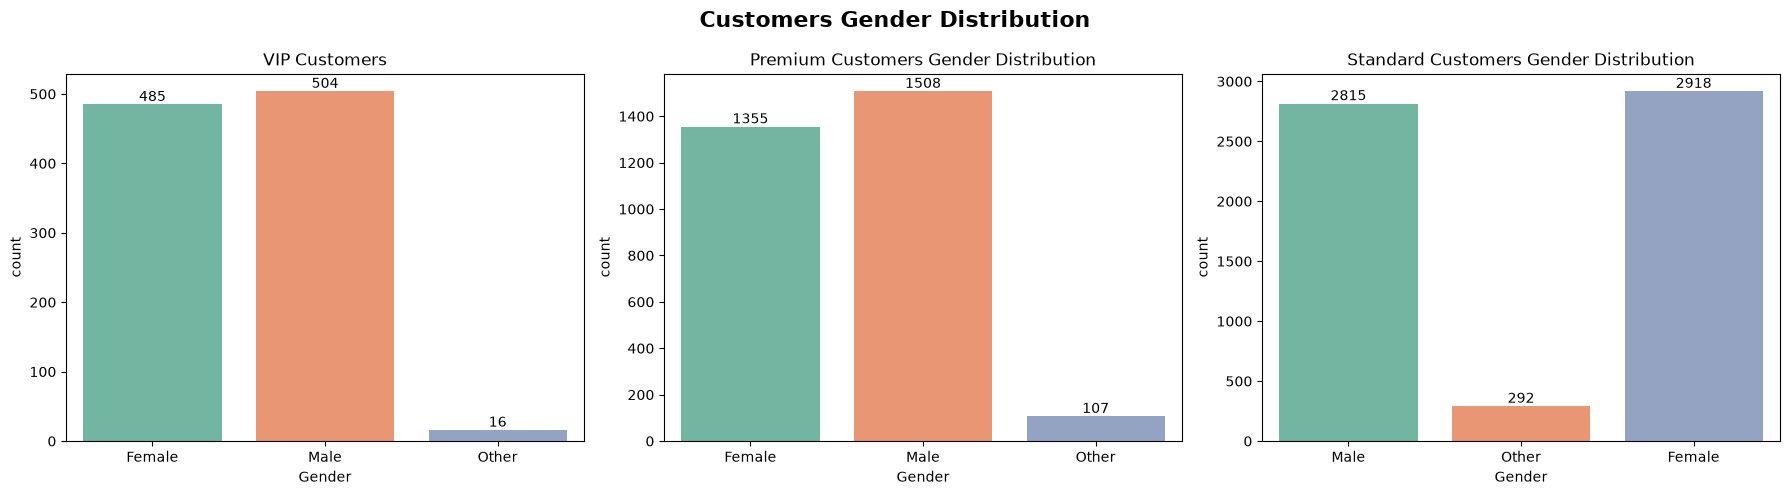

In [78]:
# for our first plot we'll look at categorical data distribution of the segments
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# VIP Customers
ax = sns.countplot(data=vip_customers, x='Gender', ax=axes[0], palette='Set2', hue='Gender', legend=False)
axes[0].set_title('VIP Customers')
# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container)
    
# Premium Customers
ax = sns.countplot(data=premium_customers, x='Gender', ax=axes[1], palette='Set2', hue='Gender', legend=False)
axes[1].set_title('Premium Customers Gender Distribution')
for container in ax.containers:
    ax.bar_label(container)

# Standard Customers
ax = sns.countplot(data=standard_customers, x='Gender', ax=axes[2], palette='Set2', hue='Gender', legend=False)
axes[2].set_title('Standard Customers Gender Distribution')
for container in ax.containers:
    ax.bar_label(container)

plt.suptitle('Customers Gender Distribution', fontsize=16, fontweight='bold')


plt.tight_layout()
plt.show()

## Observation and Analogy
- There are more male customers on the segments 'vip' and 'premium'

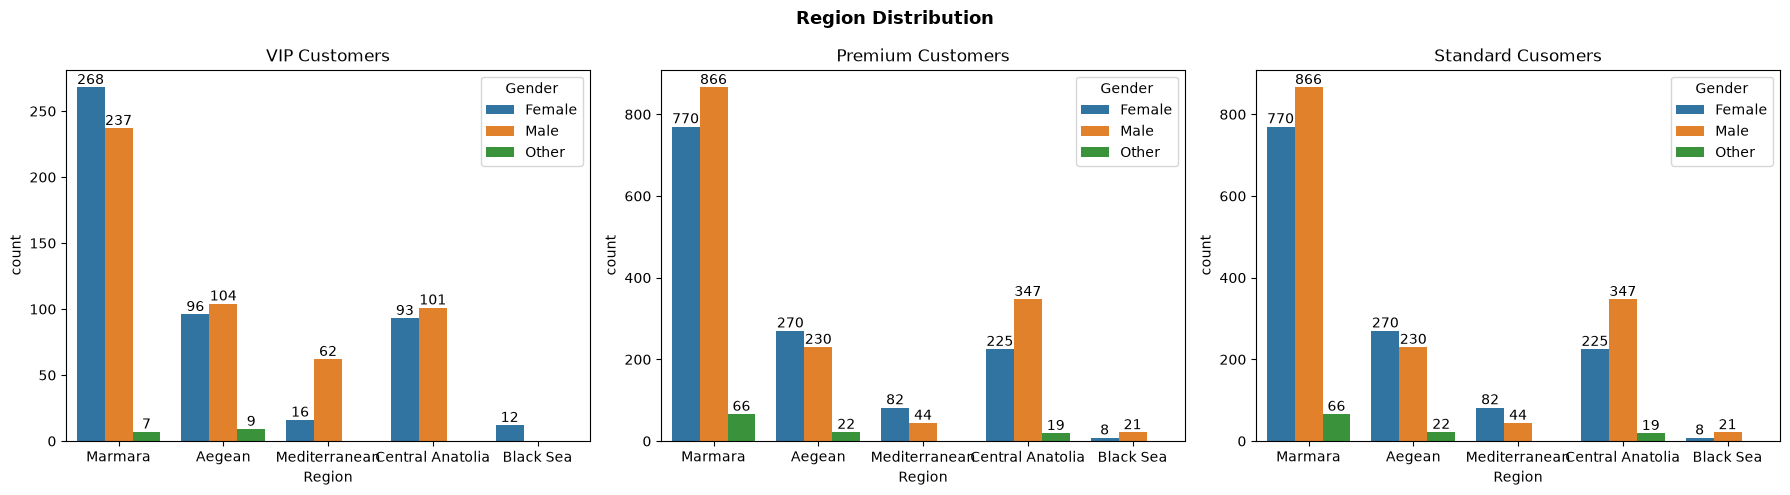

In [89]:
# City distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# VIP Customers
ax = sns.countplot(data=vip_customers, x='Region', ax=axes[0], hue='Gender')
axes[0].set_title('VIP Customers')
for container in ax.containers:
    ax.bar_label(container)
# Premium Customers
ax = sns.countplot(data=premium_customers, x='Region', ax=axes[1], hue='Gender')
axes[1].set_title('Premium Customers')
for container in ax.containers:
    ax.bar_label(container)
# Standard Customers
ax = sns.countplot(data=premium_customers, x='Region', ax=axes[2], hue='Gender')
axes[2].set_title('Standard Cusomers')
for container in ax.containers:
    ax.bar_label(container)

plt.suptitle('Region Distribution', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## Observation and Analogue  
From the plots one major observation can be seen across all segments  
That is:
- Marmara Region is leading in customers in all the Segments.
- Black Sea has the lowest number of customers in all the Segments.

# Adding Order Details  
We will have to add order details to our customer_orders to take a look at the revenue made.

In [94]:
order_details = datasets['order_details']

vip_customers = vip_customers.merge(order_details, on='OrderID')

vip_customers.isna().sum()

CustomerID            0
Gender                0
Age                   0
City                  0
Region                0
SignUpDate            0
OrderID               0
OrderDate             0
OrderTime             0
ProductID_x           0
Quantity_x            0
UnitCost_x            0
UnitPrice_x           0
DiscountRate_x        0
IsReturned_x          0
ReturnDate_x          0
ReturnTime_x          0
ReturnReason_x    28751
ProductID_y           0
Quantity_y            0
UnitCost_y            0
UnitPrice_y           0
DiscountRate_y        0
IsReturned_y          0
ReturnDate_y          0
ReturnTime_y          0
ReturnReason_y    28751
dtype: int64

In [92]:
vip_customers.head()

,CustomerID,Gender,Age,City,Region,SignUpDate,OrderID,OrderDate,OrderTime
215,CSTMR0024,Female,18,Bursa,Marmara,2022-10-09,ORD00125,2023-09-10,2026-09-07 19:53:13
216,CSTMR0024,Female,18,Bursa,Marmara,2022-10-09,ORD00812,2022-11-30,2026-09-07 12:15:59
217,CSTMR0024,Female,18,Bursa,Marmara,2022-10-09,ORD00926,2022-12-16,2026-09-07 10:13:50
218,CSTMR0024,Female,18,Bursa,Marmara,2022-10-09,ORD01890,2023-05-28,2026-09-07 19:25:29
219,CSTMR0024,Female,18,Bursa,Marmara,2022-10-09,ORD03041,2025-01-14,2026-09-07 20:39:01
